In [37]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Crear ambiente
env = gym.make("CartPole-v1")

# Límites definidos para discretizar las observaciones
state_limits = [
    (-2.4, 2.4),    # posición del carro
    (-0.5, 0.5),    # velocidad del carro
    (-0.2, 0.2),    # ángulo del péndulo
    (-2.0, 2.0)     # velocidad angular
]

# Cantidad de bins por variable
# 1 y 1 significa que casi no damos importancia a posición ni velocidad
# 6 y 12 dan más importancia al ángulo y velocidad angular
bins = (1, 1, 6, 12)

# Parámetros de Q-Learning
learning_rate = 0.1
discount_factor = 0.99

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.999

num_episodes = 5000
max_steps = 500

# Crear Q-table inicializada con ceros
q_table = np.zeros(bins + (env.action_space.n,))

print("Shape de la Q-table:")
print(q_table.shape)

print("Action space:")
print(env.action_space)

print("Observation space:")
print(env.observation_space)

Shape de la Q-table:
(1, 1, 6, 12, 2)
Action space:
Discrete(2)
Observation space:
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


In [38]:
def discretize_state(observation, state_limits, bins):
    discrete_state = []

    for i in range(len(observation)):
        value = observation[i]
        low, high = state_limits[i]
        num_bins = bins[i]

        # Limitar el valor para que no se salga del rango definido
        value = np.clip(value, low, high)

        # Si solo hay 1 bin, siempre regresa índice 0
        if num_bins == 1:
            discrete_state.append(0)
        else:
            # Crear divisiones internas
            bin_edges = np.linspace(low, high, num_bins - 1)

            # Convertir valor continuo a índice discreto
            bin_index = np.digitize(value, bin_edges)

            discrete_state.append(bin_index)

    return tuple(discrete_state)

In [39]:
import imageio
from pathlib import Path
import base64
from IPython.display import HTML

# Crear ambiente con render para poder guardar frames del entrenamiento
env = gym.make("CartPole-v1", render_mode="rgb_array")

episode_rewards = []

# Lista para guardar los frames del video de entrenamiento
training_frames = []

# Grabar un episodio cada cierto número de episodios
record_every = 500

for episode in range(num_episodes):

    observation, info = env.reset()
    state = discretize_state(observation, state_limits, bins)

    total_reward = 0
    done = False

    # Decidir si este episodio se va a grabar
    record_episode = (episode == 0) or ((episode + 1) % record_every == 0)

    for step in range(max_steps):

        # Guardar frame si este episodio se está grabando
        if record_episode:
            frame = env.render()
            training_frames.append(frame)

        # Política epsilon-greedy
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # Ejecutar acción
        new_observation, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        # Discretizar nuevo estado
        new_state = discretize_state(new_observation, state_limits, bins)

        # Valor Q actual
        current_q = q_table[state + (action,)]

        # Mejor valor Q futuro
        max_future_q = np.max(q_table[new_state])

        # Actualización Q-Learning
        new_q = current_q + learning_rate * (
            reward + discount_factor * max_future_q - current_q
        )

        q_table[state + (action,)] = new_q

        # Actualizar estado
        state = new_state

        # Acumular recompensa
        total_reward += reward

        if done:
            break

    episode_rewards.append(total_reward)

    # Reducir epsilon
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay
        epsilon = max(epsilon_min, epsilon)

    # Imprimir progreso
    if (episode + 1) % 500 == 0:
        avg_reward = np.mean(episode_rewards[-500:])
        print(
            f"Episodio {episode + 1} | "
            f"Recompensa promedio últimos 500: {avg_reward:.2f} | "
            f"Epsilon: {epsilon:.3f}"
        )

env.close()

print("Entrenamiento terminado.")
print("Frames guardados para video:", len(training_frames))

training_video_path = Path("video_entrenamiento_qlearning.mp4")

imageio.mimsave(training_video_path, training_frames, fps=30)

print("Video de entrenamiento guardado en:", training_video_path)

video_bytes = training_video_path.read_bytes()
video_base64 = base64.b64encode(video_bytes).decode("utf-8")

HTML(f"""
<video width="700" controls>
    <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
</video>
""")

Episodio 500 | Recompensa promedio últimos 500: 39.18 | Epsilon: 0.606
Episodio 1000 | Recompensa promedio últimos 500: 120.30 | Epsilon: 0.368
Episodio 1500 | Recompensa promedio últimos 500: 176.35 | Epsilon: 0.223
Episodio 2000 | Recompensa promedio últimos 500: 180.69 | Epsilon: 0.135
Episodio 2500 | Recompensa promedio últimos 500: 186.52 | Epsilon: 0.082
Episodio 3000 | Recompensa promedio últimos 500: 190.22 | Epsilon: 0.050
Episodio 3500 | Recompensa promedio últimos 500: 196.40 | Epsilon: 0.030
Episodio 4000 | Recompensa promedio últimos 500: 196.79 | Epsilon: 0.018
Episodio 4500 | Recompensa promedio últimos 500: 198.75 | Epsilon: 0.011


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Episodio 5000 | Recompensa promedio últimos 500: 194.99 | Epsilon: 0.010
Entrenamiento terminado.
Frames guardados para video: 1607
Video de entrenamiento guardado en: video_entrenamiento_qlearning.mp4


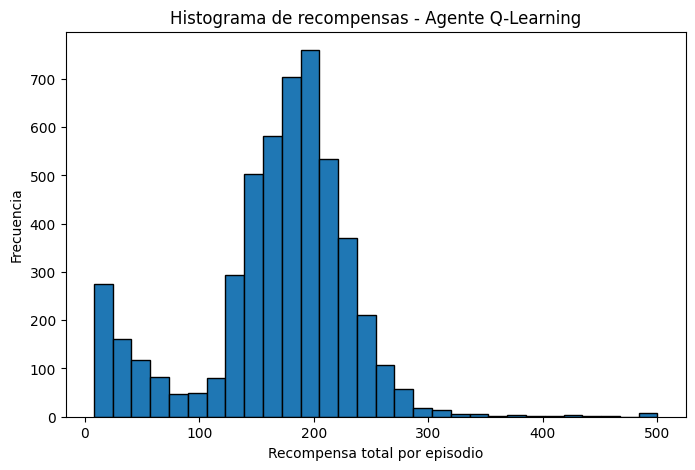

In [40]:
plt.figure(figsize=(8, 5))
plt.hist(episode_rewards, bins=30, edgecolor="black")

plt.title("Histograma de recompensas - Agente Q-Learning")
plt.xlabel("Recompensa total por episodio")
plt.ylabel("Frecuencia")

plt.show()

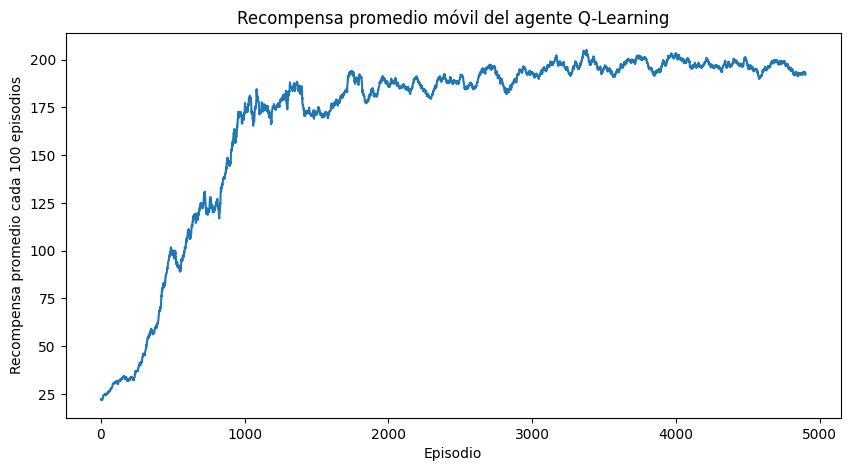

In [41]:
window = 100
moving_average = np.convolve(
    episode_rewards, 
    np.ones(window) / window, 
    mode="valid"
)

plt.figure(figsize=(10, 5))
plt.plot(moving_average)

plt.title("Recompensa promedio móvil del agente Q-Learning")
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio cada 100 episodios")

plt.show()

In [42]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

observation, info = env.reset()
state = discretize_state(observation, state_limits, bins)

done = False
total_reward = 0

while not done:

    # Ya no usamos acción aleatoria
    action = np.argmax(q_table[state])

    observation, reward, terminated, truncated, info = env.step(action)

    state = discretize_state(observation, state_limits, bins)

    total_reward += reward

    done = terminated or truncated

env.close()

print("Recompensa total del agente entrenado:", total_reward)

Recompensa total del agente entrenado: 217.0
